In [1]:
%load_ext autoreload
%autoreload 2

In [62]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import cartopy.crs as ccrs
import CM4Xutils #needed to run: pip install nc-time-axis
from regionate import MaskRegions, GriddedRegion
import seaborn as sns
import sys
import matplotlib.ticker as mticker
import sectionate
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client
import glob
import cmocean.cm as cmo
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
from isopycnal_plot_formatting import *
sns.set_theme(context='notebook', style='ticks')

print(f"Sectionate version: {sectionate.__version__}")
print('xgcm version', xgcm.__version__, '\nregionate version', regionate.__version__, '\nxwmt version', xwmt.__version__, '\nxwmb version', xwmb.__version__)

Sectionate version: 0.3.0
xgcm version 0.9.1.dev6+gc9d4302b1 
regionate version 0.5.1 
xwmt version 0.1.0 
xwmb version 0.5.0


In [161]:
get_transports = lambda ds: ds[["umo", "vmo", "thkcello", "sigma2_i", "zos"]]
datadir = lambda x="" : "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/" + x

ds_new = xr.open_mfdataset(
        datadir("model/budgets_sigma2_1p5/CM4Xp125_budgets_sigma2_2020-2024.zarr"),
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=True,
        preprocess = get_transports, 
        engine="zarr")
ds_new = ds_new.fillna(0.0)

ds_old = xr.open_mfdataset(
        datadir("model/CM4Xp125_budgets_sigma2_2020-2024.zarr"),
        data_vars="minimal",
        coords="minimal",
        compat="override",
        parallel=True,
        preprocess = get_transports, 
        engine="zarr")
ds_old = ds_old.reindex(sigma2_l=ds_new["sigma2_l"], fill_value=0.0)
ds_old = ds_old.fillna(0.0)

In [162]:
def get_psi_mean(ds):
    grid = CM4Xutils.ds_to_grid(ds, Zprefix = "sigma2")
    
    #time mean velocity and thickenss
    vmo  = ds['vmo'].mean(dim='time')
    thk  = ds['thkcello'].mean(dim='time', skipna = True)
    thk_cumsum = thk.cumsum(dim='sigma2_l')
    #estimate depth
    
    zrho = thk.cumsum(dim='sigma2_l').mean(dim='xh') #don't mask land cells
    # zrho_masked = thk.where(thk > 0).cumsum(dim='sigma2_l').mean(dim='xh') #mask land cells
    zrho_masked = thk_cumsum.where(thk_cumsum > 0).mean(dim='xh', skipna=True) #mask land cells
    
    vmo_xsum = vmo.sum(dim='xh', skipna = True) 
    psi      = (vmo_xsum.cumsum(dim='sigma2_l') - vmo_xsum.sum(dim='sigma2_l'))/1e9 
    psi.name = 'meridional-sigma2 overturning'
    
    # defined by zonal mean of the time mean depth of rho
    psi.coords['depth'] = grid.interp(zrho, 'Y', boundary='extend')
    psi.coords['depth_masked'] = grid.interp(zrho_masked, 'Y', boundary='extend')
    
    psi.coords['geolat'] = ds["geolat_v"].mean(dim='xh')
    return psi.compute()

In [163]:
psi_new = get_psi_mean(ds_new)
psi_old = get_psi_mean(ds_old)

Text(0.5, 1.0, 'magnitude of largest vmo difference\nin water column')

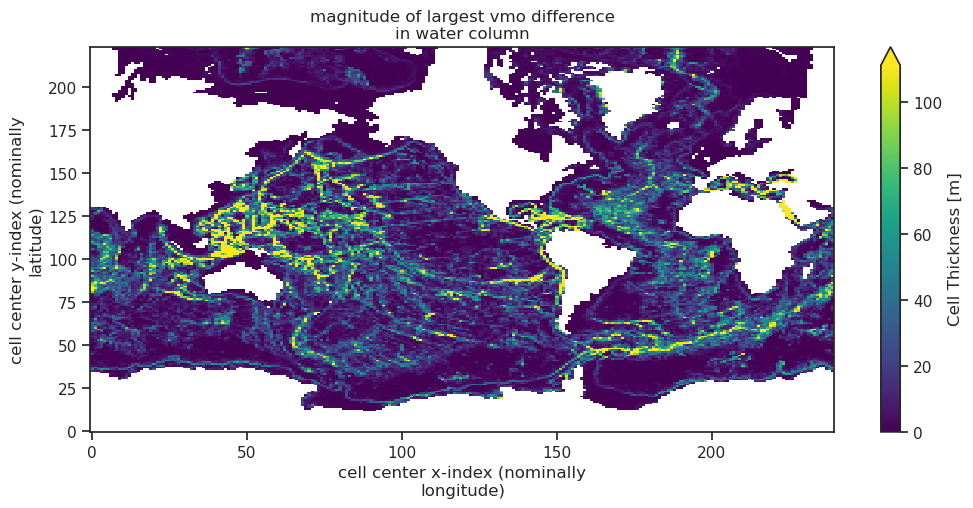

In [172]:
fig, ax = plt.subplots(figsize = (12, 5))

diff = np.abs(ds_new.sel(exp = "control").mean("time").thkcello - ds_old.sel(exp = "control").mean("time").thkcello)
diff.where(diff.wet > 0).max("sigma2_l").plot(ax = ax, robust = True)
ax.set_title("magnitude of largest vmo difference\nin water column")

# fig.savefig("umo_vmo_maximum_global.png", dpi = 150) 


In [ ]:
(ds_new.sel(exp = "control").mean("time").thkcello.sum("sigma2_l")  - ds_new.deptho).plot()

Text(0.5, 1.0, 'magnitude of largest vmo difference\nin water column')

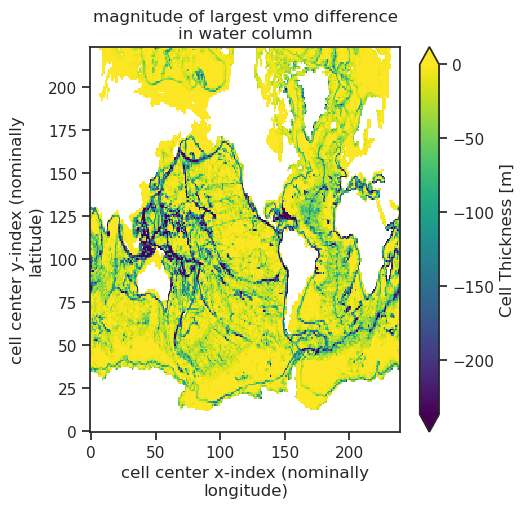

In [176]:
fig, ax = plt.subplots(figsize = (5, 5))

diff = ds_new.sel(exp = "control").mean("time").thkcello - ds_old.sel(exp = "control").mean("time").thkcello
diff.sum("sigma2_l").where(diff.wet > 0).plot(ax = ax, robust = True)
ax.set_title("magnitude of largest vmo difference\nin water column")

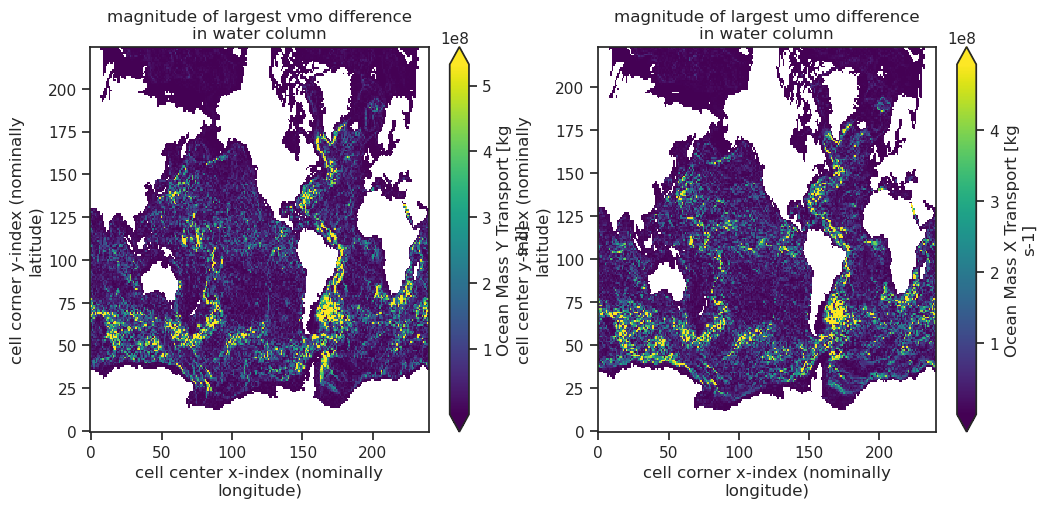

In [155]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))

diff = np.abs(ds_new.sel(exp = "control").mean("time").vmo - ds_old.sel(exp = "control").mean("time").vmo)
diff.where(diff.wet_v > 0).max("sigma2_l").plot(ax = ax[0], robust = True)
ax[0].set_title("magnitude of largest vmo difference\nin water column")

diff = np.abs(ds_new.sel(exp = "control").mean("time").umo - ds_old.sel(exp = "control").mean("time").umo)
diff.where(diff.wet_u > 0).max("sigma2_l").plot(ax = ax[1], robust = True)
ax[1].set_title("magnitude of largest umo difference\nin water column")

fig.savefig("umo_vmo_maximum_global.png", dpi = 150) 


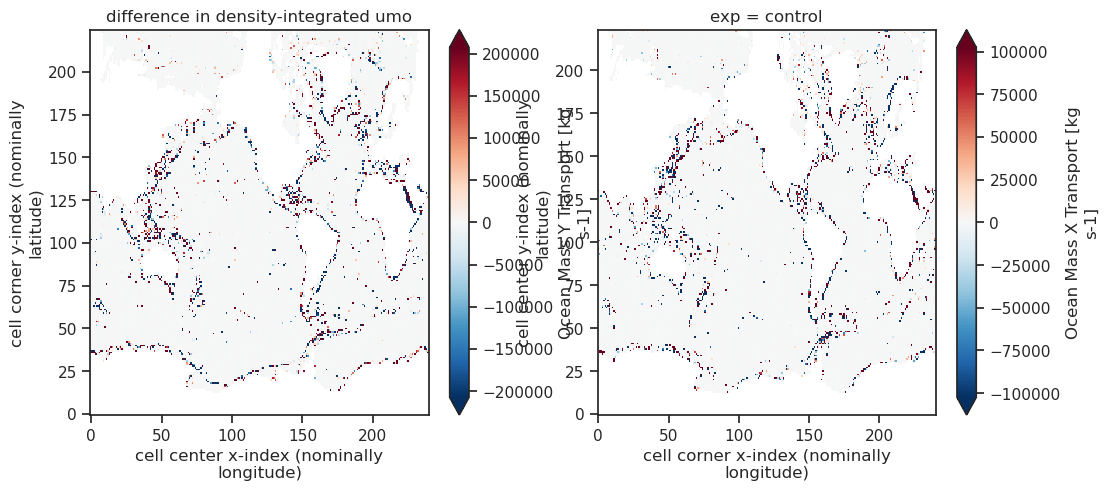

In [153]:
fig, ax = plt.subplots(1, 2, figsize = (12, 5))


diff = (ds_new.sel(exp = "control").mean("time").vmo - ds_old.sel(exp = "control").mean("time").vmo).sum("sigma2_l")
diff.where(diff.wet_v > 0).plot(ax = ax[0], robust = True)
ax[0].set_title("difference in density-integrated vmo")

diff = (ds_new.sel(exp = "control").mean("time").umo - ds_old.sel(exp = "control").mean("time").umo).sum("sigma2_l")
diff.where(diff.wet_u > 0).plot(ax = ax[1], robust = True)
ax[1].set_title("difference in density-integrated umo")

fig.savefig("umo_vmo_integrated_global.png", dpi = 150) 


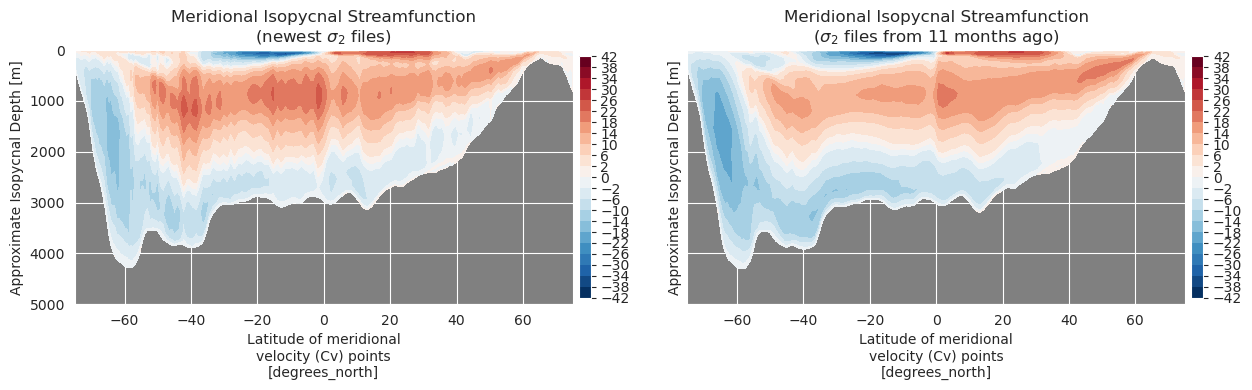

In [35]:
#define streamfunction levels
levels = [-42, -38, -34, -30, -26, -22, -18, -14, -10, -6, -2, 
           0,   2,   6,  10,  14,  18,  22,  26,  30,  34,  38,  42]

#select experiment 
exp = "control"

# create one figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

# first subplot: depth
ax = axes[0]
p1 = psi_new.sel(exp=exp).plot.contourf(
    ax=ax, x="geolat", y="depth", levels=levels,
    add_colorbar=False, cmap='RdBu_r'
)
c1 = fig.colorbar(p1, ax=ax, pad=0.01, spacing='uniform',
                  extend='both', shrink=0.95, orientation='vertical')
c1.set_ticks(levels)
c1.ax.tick_params(labelsize=10)
ax.set_facecolor('gray')
ax.set_xlim(-75, 75)
ax.set_ylim(0, 5000)
ax.invert_yaxis()
ax.set_ylabel("Approximate Isopycnal Depth [m]")
# ax.vlines([-65], 0, 5000, colors = "k", linestyle = "--")
ax.set_title(f"Meridional Isopycnal Streamfunction\n(newest $\sigma_2$ files)")

# second subplot: depth_masked
ax = axes[1]
p1 = psi_old.sel(exp=exp).plot.contourf(
    ax=ax, x="geolat", y="depth", levels=levels,
    add_colorbar=False, cmap='RdBu_r'
)
c1 = fig.colorbar(p1, ax=ax, pad=0.01, spacing='uniform',
                  extend='both', shrink=0.95, orientation='vertical')
c1.set_ticks(levels)
c1.ax.tick_params(labelsize=10)
ax.set_facecolor('gray')
ax.set_xlim(-75, 75)
# ax.vlines([-65], 0, 5000, colors = "k", linestyle = "--")
ax.set_ylim(0, 5000)
ax.invert_yaxis()
ax.set_ylabel("Approximate Isopycnal Depth [m]")
ax.set_title(f"Meridional Isopycnal Streamfunction\n($\sigma_2$ files from 11 months ago)")
fig.tight_layout()
fig.savefig("Streamfunction_Comp.png", dpi = 400) 

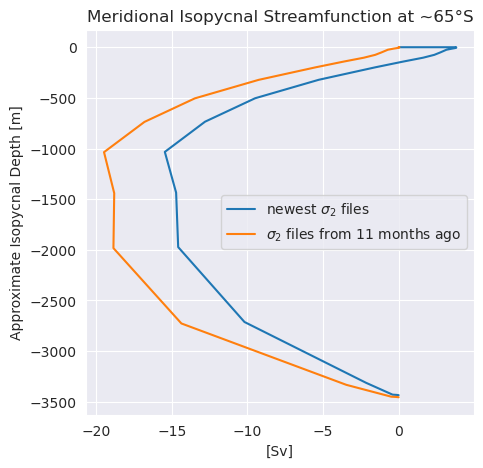

In [36]:
fig, ax = plt.subplots(figsize = (5, 5))
ax.plot(psi_new.sel(exp = "control").isel(yq = 40), -psi_new.depth.sel(exp = "control").isel(yq = 40), label = r"newest $\sigma_2$ files")
ax.plot(psi_old.sel(exp = "control").isel(yq = 40), -psi_old.depth.sel(exp = "control").isel(yq = 40), label = r"$\sigma_2$ files from 11 months ago")
ax.legend()

ax.set_title(f"Meridional Isopycnal Streamfunction at ~65°S")
ax.set_xlabel("[Sv]")
ax.set_ylabel("Approximate Isopycnal Depth [m]")
fig.savefig("Streamfunction_Comp_at65S.png", dpi = 400) 

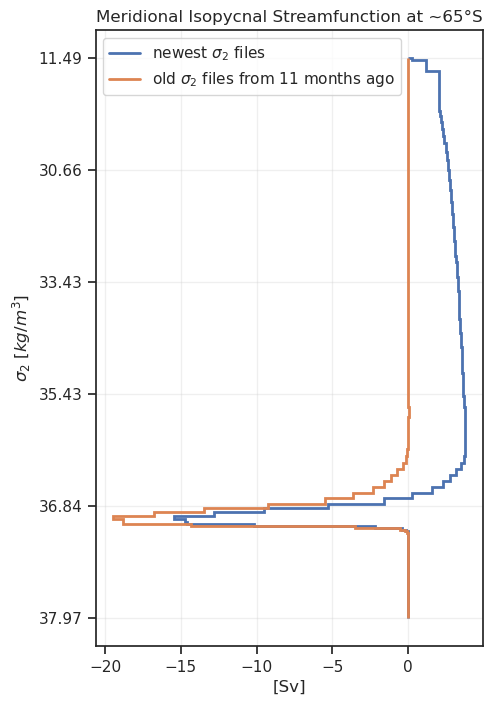

In [116]:
new_values = psi_new.sel(exp = "control").isel(yq = 40).sel(sigma2_l = slice(10, 38.1))
old_values = psi_old.sel(exp = "control").isel(yq = 40).sel(sigma2_l = slice(10, 38.1))
density =  ds_new.sigma2_i.sel(sigma2_i = slice(10, 38.1))


telescope_power = 5
transformed_density = density_transform(density, telescope_power)

fig, ax = plt.subplots(figsize = (5, 8))
ax.stairs(new_values, transformed_density, label = r"newest $\sigma_2$ files", lw = 2, orientation = "horizontal")
ax.stairs(old_values, transformed_density, label = r"old $\sigma_2$ files from 11 months ago", lw = 2, orientation = "horizontal")
ax.legend()

ax.set_title(f"Meridional Isopycnal Streamfunction at ~65°S")
ax.set_xlabel("[Sv]")

formatter = create_density_formatter(density, transformed_density)
ax.tick_params(bottom=True, left=True)
ax.set_ylabel(r"$\sigma_2$" + " " + r"$[kg/m^3]$")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
ax.invert_yaxis()
fig.savefig("Streamfunction_Comp_at65S_isopycnal.png", dpi = 400) 
ax.grid(alpha = 0.3)

In [122]:
new_values = ds_new.isel(xq = 175, yh = 25, xh = 175, yq = 25).sel(exp = "control").mean("time").sel(sigma2_l = slice(-2000, 38.1))
old_values = ds_old.isel(xq = 175, yh = 25, xh = 175, yq = 25).sel(exp = "control").mean("time").sel(sigma2_l = slice(-2000, 38.1))

new_values = new_values.compute()
old_values = old_values.compute()
density =  ds_new.sigma2_i.sel(sigma2_i = slice(-2000, 38.1))


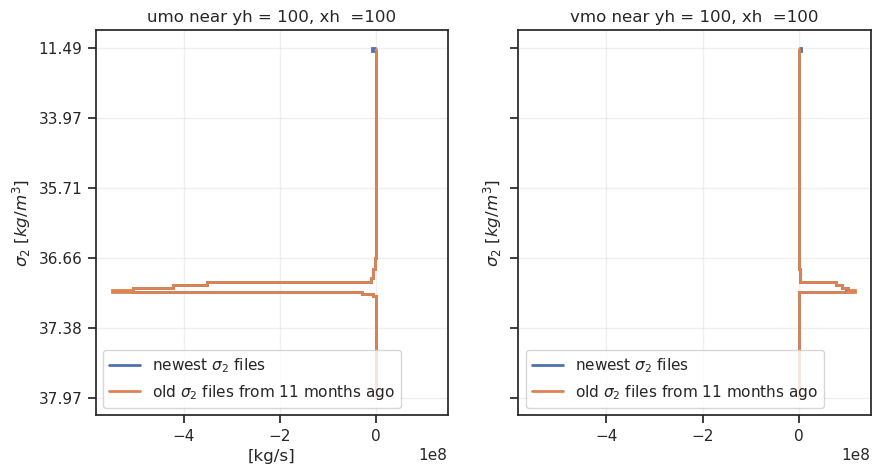

In [121]:
telescope_power = 10
transformed_density = density_transform(density, telescope_power)
formatter = create_density_formatter(density, transformed_density)

fig, axes = plt.subplots(1, 2, figsize = (10, 5), sharey = True, sharex = True)
axes[0].stairs(new_values.umo, transformed_density, label = r"newest $\sigma_2$ files", lw = 2, orientation = "horizontal")
axes[0].stairs(old_values.umo, transformed_density, label = r"old $\sigma_2$ files from 11 months ago", lw = 2, orientation = "horizontal")
axes[0].legend()

axes[0].set_title(f"umo near yh = 100, xh  =100")
axes[0].set_xlabel("[kg/s]")


axes[1].stairs(new_values.vmo, transformed_density, label = r"newest $\sigma_2$ files", lw = 2, orientation = "horizontal")
axes[1].stairs(old_values.vmo, transformed_density, label = r"old $\sigma_2$ files from 11 months ago", lw = 2, orientation = "horizontal")
axes[1].legend()

axes[1].set_title(f"vmo near yh = 100, xh  =100")


for ax in axes:
    ax.tick_params(bottom=True, left=True)
    ax.set_ylabel(r"$\sigma_2$" + " " + r"$[kg/m^3]$")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
    ax.grid(alpha = 0.3)

ax.invert_yaxis()

fig.savefig("umo_vmo_at_point_isopycnal.png", dpi = 400) 
